# Magnetic Shielding Calculation at Arbitrary Points, General

## Imports

In [10]:
# Deactivate warnings
import warnings
warnings.filterwarnings('ignore')
from pyscf import gto, scf
import numpy as np

# Conversion Å to Bohr
ANG2BOHR = 1.8897259886

print('PySCF version:', gto.__version__ if hasattr(gto, '__version__') else 'OK')
print('Imports OK')

PySCF version: OK
Imports OK


In [ ]:
# Load utility functions from GitHub
from urllib.request import urlopen

github_url = 'https://raw.githubusercontent.com/ycarissan/echem-ycarissan/main/shielding_utils.py'
try:
    with urlopen(github_url) as response:
        exec(response.read().decode('utf-8'))
    print("✓ Utility functions loaded from GitHub")
except Exception as e:
    print(f"Could not load from GitHub: {e}")
    print("  Attempting to load from local file...")
    try:
        with open('shielding_utils.py', 'r') as f:
            exec(f.read())
        print("Utility functions loaded from local file")
    except Exception as e2:
        print(f"Error loading utility functions: {e2}")


✓ Utility functions loaded from GitHub


## NICS map on a 2D grid

A regular grid is generated in the molecular plane (z = 0) and the shielding is computed at each point.

In [12]:
# Benzene (C6H6)
BENZENE = """
C    0.000000   1.394707   0.000000
C    0.000000  -1.394707   0.000000
C    1.147376   0.718445   0.000000
C   -1.147376   0.718445   0.000000
C    1.147376  -0.718445   0.000000
C   -1.147376  -0.718445   0.000000
H    0.000000   2.479737   0.000000
H    0.000000  -2.479737   0.000000
H    2.033173   1.242049   0.000000
H   -2.033173   1.242049   0.000000
H    2.033173  -1.242049   0.000000
H   -2.033173  -1.242049   0.000000
"""
HEXATRIENE = """
C           0.606       -0.300      0.000       
C           -0.606      0.300       0.000       
C           1.870       0.410       0.000       
C           -1.870      -0.410      0.000       
C           3.075       -0.186      0.000       
C           -3.075      0.186       0.000       
H           0.657       -1.390      0.000       
H           -0.657      1.390       0.000       
H           1.814       1.499       0.000       
H           -1.814      -1.499      0.000       
H           3.997       0.388       0.000       
H           -3.997      -0.388      0.000       
H           3.173       -1.269      0.000       
H           -3.173      1.269       0.000       
"""
BUTADIENE = """
C   -1.476   1.108   0.000
C   -0.729   0.000   0.000
C    0.729   0.000   0.000
C    1.476  -1.108   0.000
H   -1.000   2.084   0.000
H   -2.560   1.032   0.000
H   -1.272  -0.941   0.000
H    1.272   0.941   0.000
H    2.560  -1.032   0.000
H    1.000  -2.084   0.000
"""
CYCLOBUTADIENE = """
C    0.000000   1.397500   0.000000
C    1.397500   0.000000   0.000000
C    0.000000  -1.397500   0.000000
C   -1.397500   0.000000   0.000000
H    0.000000   2.483500   0.000000
H    2.483500   0.000000   0.000000
H    0.000000  -2.483500   0.000000
H   -2.483500   0.000000   0.000000
"""
NAPHTALENE = """
C          2.45076       -0.71174        0.00000
C          2.45076        0.71174        0.00000
C          1.25139        1.41137        0.00000
C         -0.00000        0.72289        0.00000
C         -1.25139        1.41137        0.00000
C         -2.45076        0.71174        0.00000
C         -2.45076       -0.71174        0.00000
C         -1.25139       -1.41137        0.00000
C         -0.00000       -0.72289        0.00000
C          1.25139       -1.41137        0.00000
H          3.40873       -1.25791        0.00000
H          3.40873        1.25791        0.00000
H          1.24972        2.51472        0.00000
H         -1.24972        2.51472        0.00000
H         -3.40873        1.25791        0.00000
H         -3.40873       -1.25791        0.00000
H         -1.24972       -2.51472        0.00000
H          1.24972       -2.51472        0.00000
"""
ACROLEIN = """
 O      -1.808864   -0.137998    0.000000
 C       1.769114    0.136549    0.000000
 C       0.588145   -0.434423    0.000000
 C      -0.695203    0.361447    0.000000
 H      -0.548852    1.455362    0.000000
 H       0.477859   -1.512556    0.000000
 H       2.688665   -0.434186    0.000000
 H       1.880903    1.213924    0.000000
"""
AZULENE = """
C      0.000000    0.000000    0.000000
C      0.000000    1.500000    0.000000
C      1.426585    1.963525    0.000000
C      2.308263    0.750000    0.000000
C      1.426585   -0.463525    0.000000
C     -1.251859   -0.826346    0.000000
C     -1.386317   -2.320308    0.000000
C     -0.302123   -3.356900    0.000000
C      1.184301   -3.155547    0.000000
C      1.953647   -1.867872    0.000000
H     -0.889919    2.146564    0.000000
H      1.766503    3.009688    0.000000
H      3.408263    0.750000    0.000000
H     -2.196154   -0.262158    0.000000
H     -2.416175   -2.706821    0.000000
H     -0.642040   -4.403063    0.000000
H      1.790290   -4.073576    0.000000
H      3.049219   -1.966473    0.000000
"""
PERYLENE = """
 C                 -1.24677599   -3.52839684    0.00000000
 C                 -0.00000000   -2.83779392    0.00000000
 C                 -0.00000000   -1.42912254    0.00000000
 C                 -1.23765126   -0.71455675    0.00000000
 C                 -2.43231472   -2.84393011    0.00000000
 C                  1.23765126   -0.71455675   -0.00000000
 C                 -1.23765126    0.71455675   -0.00000000
 C                 -0.00000000    1.42912254    0.00000000
 C                  1.23765126    0.71455675    0.00000000
 C                 -0.00000000    2.83779392    0.00000000
 C                 -1.24677599    3.52839684   -0.00000000
 C                 -2.43231472    2.84393011   -0.00000000
 H                 -1.23389981   -4.62908118    0.00000000
 H                 -3.39197762   -3.38310643    0.00000000
 H                 -1.23389981    4.62908118   -0.00000000
 H                 -3.39197762    3.38310643   -0.00000000
 C                  1.24677599   -3.52839684   -0.00000000
 C                  2.43231472   -2.84393011   -0.00000000
 H                  1.23389981   -4.62908118   -0.00000000
 H                  3.39197762   -3.38310643   -0.00000000
 C                  1.24677599    3.52839684    0.00000000
 H                  1.23389981    4.62908118    0.00000000
 C                  2.43231472    2.84393011    0.00000000
 H                  3.39197762    3.38310643    0.00000000
 C                  2.45760117    1.41888741    0.00000000
 H                  3.35058749    0.82941702    0.00000000
 C                  2.45760117   -1.41888741    0.00000000
 H                  3.35058749   -0.82941702    0.00000000
 C                 -2.45760117    1.41888741    0.00000000
 H                 -3.35058749    0.82941702    0.00000000
 C                 -2.45760117   -1.41888741    0.00000000
 H                 -3.35058749   -0.82941702    0.00000000
 """

GEOM=NAPHTALENE

# Parameters
BASIS = '6-311+G(d,p)'   # basis
BASIS = '6-31G'   # basis
BASIS = 'sto-3g'   # basis
BASIS = 'cc-pvdz'   # basis
METHOD = 'RHF'           # 'RHF' or 'DFT-B3LYP'

print(f'Method : {METHOD}')
print(f'Basis : {BASIS}')

Method : RHF
Basis : cc-pvdz


In [13]:
# Bare molecule
mol = gto.Mole()
mol.atom  = GEOM
mol.basis = BASIS

if METHOD == 'RHF':
    mf = scf.RHF(mol)
mf.max_cycle = 200
mf.conv_tol  = 1e-10

print(f'Running {METHOD} ...')
mf.kernel()
print(f'Converged : {mf.converged}')
print(f'nao = {mol.nao}')

Running RHF ...


Initialize <pyscf.gto.mole.Mole object at 0x71275413d880> in <pyscf.scf.hf.RHF object at 0x7127540a8110>


converged SCF energy = -383.378504148417
Converged : True
nao = 180


In [14]:
# get the second column of GEOM (assuming it's the x-coordinate)
x_coords = [float(line.split()[1]) for line in GEOM.strip().split('\n')]

# get the third column of GEOM (assuming it's the y-coordinate)
y_coords = [float(line.split()[2]) for line in GEOM.strip().split('\n')]

xmin, xmax = min(x_coords), max(x_coords)
ymin, ymax = min(y_coords), max(y_coords)

# 2D grid generation in the molecular plane (z = 1.0)
grid_points = generate_grid_2d(
    xrange=(xmin, xmax),
    yrange=(ymin, ymax),
    z=1.0,
    spacing=0.2
)

#grid_points = points_ang  # Use the points from Option A or B instead of the generated grid
print(f'{len(grid_points)} grid points generated')

910 grid points generated


In [15]:
mo10, dm10_oo, dm10_vo, dm0 = solve_CPHF(mf)
# Shielding computation at each grid point
results_grid = []
for i, point in enumerate(grid_points):
    sigma = shielding_at_point(mol, dm0, dm10_oo, dm10_vo, point)
    res = analyze_shielding(sigma)
    res.update({'x': point[0], 'y': point[1], 'z': point[2], 'point_idx': i})
    results_grid.append(res)

sigma_iso_grid = np.array([r['sigma_iso'] for r in results_grid])
print(f'Done: {len(results_grid)} points computed')
print(f'σ_iso min = {sigma_iso_grid.min():.2f} ppm,  max = {sigma_iso_grid.max():.2f} ppm')

Done: 910 points computed
σ_iso min = -0.64 ppm,  max = 20.42 ppm


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

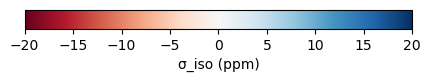

In [16]:
atoms_mol = get_molecule_coords(GEOM)
bonds = get_bond_pairs(atoms_mol)
# 3D visualization with σ_iso color scale
visualize_molecule_with_points(atoms_mol, bonds, results_grid, sigma_iso_grid, \
                               sphere_radius=0.1, opacity_grid=0.99, vmax=20)

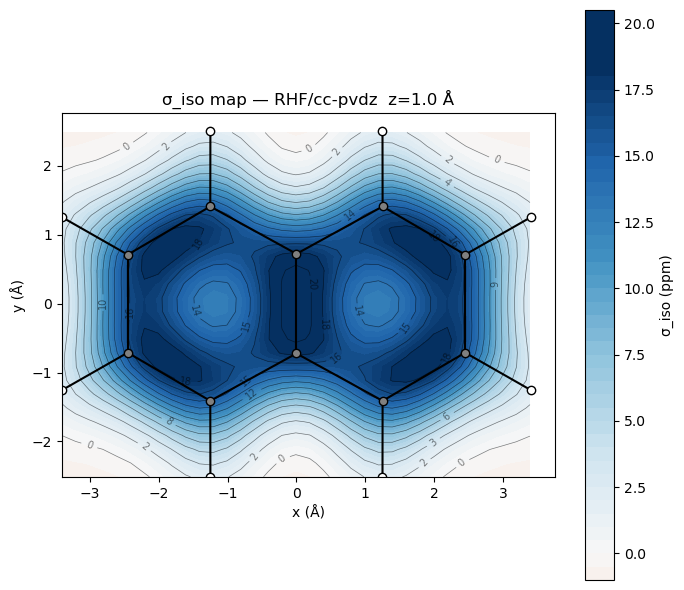

In [17]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Reshape 1D grid data back to 2D
xs = np.array([r['x'] for r in results_grid])
ys = np.array([r['y'] for r in results_grid])
sigma = np.array([r['sigma_iso'] for r in results_grid])

x_unique = np.unique(xs)
y_unique = np.unique(ys)
nx, ny = len(x_unique), len(y_unique)

X = xs.reshape(ny, nx)
Y = ys.reshape(ny, nx)
Z = sigma.reshape(ny, nx)

# Symmetric color scale centred on zero (NICS: negative=aromatic, positive=antiaromatic)
vmax = np.percentile(np.abs(sigma), 95)
norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

fig, ax = plt.subplots(figsize=(7, 6))

# Filled surface
cf = ax.contourf(X, Y, Z, levels=50, cmap='RdBu', norm=norm)
plt.colorbar(cf, ax=ax, label='σ_iso (ppm)')

# Isocontour lines
cs = ax.contour(X, Y, Z, levels=20, colors='k', linewidths=0.5, alpha=0.5)
ax.clabel(cs, fmt='%.0f', fontsize=7)

# Molecule skeleton
for (i, j) in bonds:
    ax.plot(
        [atoms_mol[i]['x'], atoms_mol[j]['x']],
        [atoms_mol[i]['y'], atoms_mol[j]['y']],
        'k-', lw=1.5
    )

# Atom markers
for a in atoms_mol:
    color = {'C': 'grey', 'H': 'white'}.get(a['symbol'], 'blue')
    ax.plot(a['x'], a['y'], 'o', color=color, markersize=6, markeredgecolor='k', lw=0.5)

ax.set_aspect('equal')
ax.set_xlabel('x (Å)')
ax.set_ylabel('y (Å)')
ax.set_title(f'σ_iso map — {METHOD}/{BASIS}  z={grid_points[0][2]:.1f} Å')
plt.tight_layout()
plt.show()
